# Semantic mask generator
Tidak perlu melakukan inference dengan model segmentasi seperti yolo.
Cukup dengan mengambil dari dataset lama yang ada dan melakukan upsampling dengan opencv. Jika tidak punya silahkan pertimbangkan untuk membuat atau menggunakan inferensi model segmentasi khusus dan tambahkan kode di bawah. 

In [36]:
import re
import os
import cv2
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt

In [ ]:
def resize_mask(filename):
    image = cv2.imread(filename)
    resized = cv2.resize(image, (1280, 720), cv2.INTER_CUBIC)
    return image, resized

def list_images(input_dir, recursive=False):
    """
    Mengambil gambar dari folder utama.

    Default recursive=True supaya struktur seperti ini bisa diproses:
        folder_utama/
            folder_data_1/gambarstereo1-1.jpg
            folder_data_2/gambarstereo2-1.jpg

    Jika recursive=False, hanya gambar langsung di input_dir yang dibaca.
    """

    IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    input_dir = Path(input_dir)

    if recursive:
        candidates = input_dir.rglob("*")
    else:
        candidates = input_dir.iterdir()

    images = [
        p for p in candidates
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    return sorted(images, key=lambda p: natural_key(p.relative_to(input_dir)))

def natural_key(path):
    """Natural sorting untuk nama file: frame-2 sebelum frame-10."""
    text = str(path)
    return [int(s) if s.isdigit() else s.lower() for s in re.split(r"(\d+)", text)]

def main(input_dir, output_dir):
    images = Path(input_dir)
    images = list_images(input_dir)

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    if len(images) == 0:
        raise FileNotFoundError(f"Tidak ada gambar di folder: {input_dir}")
    print(f'Total file: {len(images)}')
    print(images[0])
    
    try:
        for idx, image_path in enumerate(images, start=1):
            print("\n" + "#" * 80)
            print(f"[{idx}/{len(images)}] Processing: {image_path.name}")

            try:
                raw_image, resized_image = resize_mask(image_path)
                cv2.imwrite(os.path.join(output_dir, image_path.name), resized_image)

            except Exception as exc:
                print(f"[FAILED] {image_path.name}")
                print(f"Reason: {exc}")
    finally:
        print("Succesfully resizing and saving")
    return resized_image

Total file: 5059
/home/dionsetiawan/Documents/Riset/Progress-Tesis/thesis_ws/HaOri-6D/yon-poseCNN/data/A-cleardataset/masks/amik-img-1-M-frame-0-2024-06-07_234721_0.png

################################################################################
[1/5059] Processing: amik-img-1-M-frame-0-2024-06-07_234721_0.png

################################################################################
[2/5059] Processing: amik-img-1-M-frame-4-2024-06-07_234721_0.png

################################################################################
[3/5059] Processing: amik-img-1-M-frame-8-2024-06-07_234721_0.png

################################################################################
[4/5059] Processing: amik-img-1-M-frame-12-2024-06-07_234721_0.png

################################################################################
[5/5059] Processing: amik-img-1-M-frame-16-2024-06-07_234721_0.png

################################################################################
[6/5059

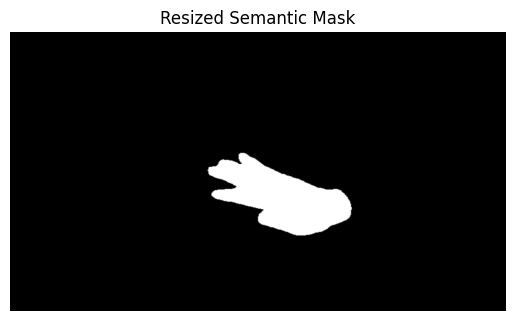

In [38]:
input_dir  = '/home/dionsetiawan/Documents/Riset/Progress-Tesis/thesis_ws/HaOri-6D/yon-poseCNN/data/A-cleardataset/masks'
output_dir = '/home/dionsetiawan/Documents/Riset/Progress-Tesis/thesis_ws/HaOri-6D/yon-poseCNN/data-extraction/pseudo_dataset_08072026/semantic'
mask = main(input_dir, output_dir)

# raw, resized = resize_mask(filename)
# # image = np.hstack([raw, resized])
plt.title("Resized Semantic Mask")
plt.axis("off")
plt.imshow(mask)